In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv('troop_movements.csv')

# Create grouped data showing counts of empire vs resistance
group_count = data.groupby('empire_or_resistance').size()
group_count_df = group_count.reset_index(name='count')

# Rename the columns for clarity
group_count_df.columns = ['empire_or_resistance', 'count']
print(group_count)


#create grouped data showing counts of characters by homeworld
# homeworld_count = data.groupby('homeworld').size()
# print(homeworld_count)

empire_or_resistance
empire        497
resistance    503
dtype: int64


In [24]:
group_count_hw = data.groupby('homeworld').size()
group_count_df_hw = group_count_hw.reset_index(name='count')

# Rename the columns for clarity
group_count_df_hw.columns = ['homeworld', 'count']
print(group_count_hw)


homeworld
Alderaan        29
Aleen Minor     17
Bestine IV      25
Cerea           29
Champala        31
Chandrila       19
Concord Dawn    18
Corellia        25
Dagobah         24
Dathomir        22
Dorin           25
Eriadu          16
Glee Anselm     20
Haruun Kal      20
Iktotch         27
Iridonia        18
Kalee           27
Kashyyyk        24
Malastare       24
Mirial          21
Mon Cala        22
Muunilinst      21
Naboo           14
Ojom            38
Quermia         26
Rodia           27
Ryloth          31
Serenno         34
Shili           19
Skako           27
Socorro         21
Stewjon         24
Sullust         30
Tatooine        17
Tholoth         24
Toydaria        25
Trandosha       26
Troiken         22
Tund            18
Umbara          22
Vulpter         22
Zolan           29
dtype: int64


In [25]:
unit_df = data.groupby('unit_type').size()
unitDF = unit_df.reset_index(name='count')

# Rename the columns for clarity
unitDF.columns = ['unit_type', 'count']
print(unit_df)

unit_type
at-at                 121
at-st                 113
resistance_soldier    138
stormtrooper          118
tie_fighter           115
tie_silencer          138
unknown               130
x-wing                127
dtype: int64


In [26]:
data['is_resistance'] = data['empire_or_resistance'] == 'resistance'
display(data)

,timestamp,unit_id,unit_type,empire_or_resistance,location_x,location_y,destination_x,destination_y,homeworld,is_resistance
0,2025-03-17 15:02:52,1,at-at,empire,4,3,7,2,Skako,False
1,2025-03-17 15:02:51,2,at-at,resistance,9,2,6,8,Cerea,True
2,2025-03-17 15:02:50,3,tie_fighter,empire,4,2,5,5,Mirial,False
3,2025-03-17 15:02:49,4,at-at,resistance,6,2,1,1,Kalee,True
4,2025-03-17 15:02:48,5,tie_silencer,resistance,6,5,4,1,Alderaan,True
...,...,...,...,...,...,...,...,...,...,...
995,2025-03-17 14:46:17,996,tie_fighter,resistance,8,7,8,7,Ojom,True
996,2025-03-17 14:46:16,997,tie_silencer,empire,10,1,7,2,Skako,False
997,2025-03-17 14:46:15,998,at-at,resistance,3,10,1,10,Mirial,True
998,2025-03-17 14:46:14,999,x-wing,resistance,9,4,4,2,Naboo,True


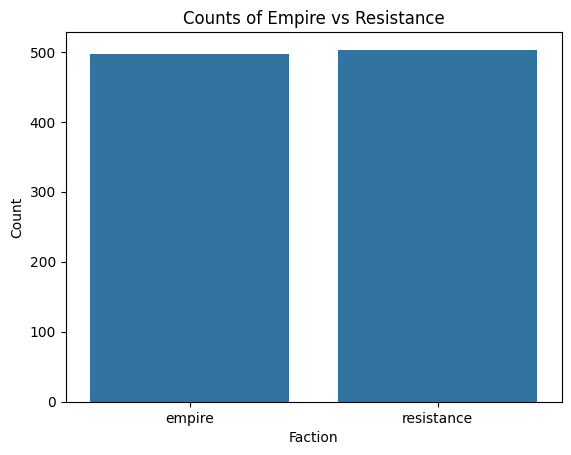

In [27]:
sns.barplot(x='empire_or_resistance', y='count', data=group_count_df)

plt.xlabel('Faction')
plt.ylabel('Count')
plt.title('Counts of Empire vs Resistance')

plt.show()

In [28]:
# Specify the path to the CSV file
output_file = "troop_movements.csv"  # Adjust the path if necessary

# Read the CSV file into a DataFrame
data = pd.read_csv(output_file)

# Encode categorical variables
label_encoder_homeworld = LabelEncoder()
label_encoder_unit_type = LabelEncoder()

data['homeworld_encoded'] = label_encoder_homeworld.fit_transform(data['homeworld'])
data['unit_type_encoded'] = label_encoder_unit_type.fit_transform(data['unit_type'])

# Define features and target
X = data[['homeworld_encoded', 'unit_type_encoded']]
y = data['empire_or_resistance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Optional: Display feature importances
feature_importances = clf.feature_importances_
print("Feature importances:", feature_importances)

Accuracy: 0.62
Feature importances: [0.67701477 0.32298523]


In [29]:
importances = clf.feature_importances_

feature_names = X.columns

feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
print(feature_importances)

             feature  importance
0  homeworld_encoded    0.677015
1  unit_type_encoded    0.322985


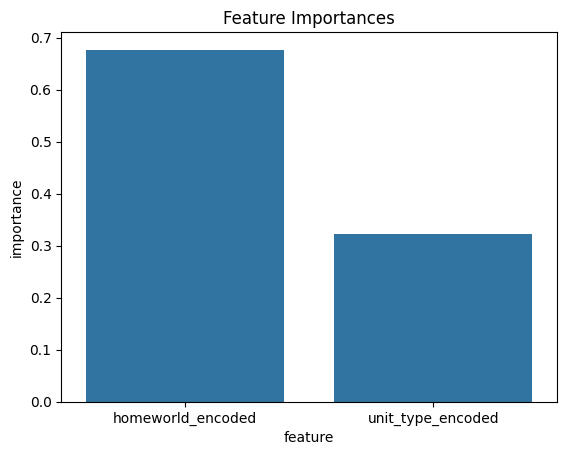

In [30]:
sns.barplot(x='feature', y='importance', data=feature_importances)

plt.xlabel('feature')
plt.ylabel('importance')
plt.title('Feature Importances')

plt.show()